In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("enzoschitini/brazilian-e-commerce-public-dataset-by-olist")

print("Path to dataset files:", path)

100%|██████████| 13.3M/13.3M [00:00<00:00, 86.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/enzoschitini/brazilian-e-commerce-public-dataset-by-olist/versions/1


In [2]:
import os

# Ver qué archivos hay en la carpeta descargada
for archivo in os.listdir(path):
    print(archivo)

Brazilian E-Commerce Public Dataset by Olist.csv


In [5]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv(path + '/Brazilian E-Commerce Public Dataset by Olist.csv')

# Primera mirada
df.head()

,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1


In [6]:
# Ver todas las columna
pd.set_option('display.max_columns', None)

# Lista completa de nombres de columnas
print(df.columns.tolist())

# Info completa: nombres, tipos y nulos de cada una
df.info()

['Unnamed: 0', 'order_id', 'order_item_id', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_id', 'seller_city', 'seller_state', 'seller_zip_code_prefix', 'payment_type', 'payment_sequential', 'payment_installments', 'price', 'freight_value', 'payment_value', 'shipping_limit_date', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'day_of_purchase', 'month_of_purchase', 'year_of_purchase', 'month/year_of_purchase', 'order_status', 'order_unique_id']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------           

In [7]:
# strings vacíos o valores tipo 'NA', 'N/A', 'nan'
for col in df.select_dtypes(include='object').columns:
    vacios = df[col].isin(['', ' ', 'NA', 'N/A', 'nan', 'None']).sum()
    if vacios > 0:
        print(f"{col}: {vacios} valores sospechosos")

# Verificar las columnas de fecha específicamente
print("\nValores únicos en fechas clave:")
print("order_delivered_customer_date sample:", df['order_delivered_customer_date'].unique()[:5])


Valores únicos en fechas clave:
order_delivered_customer_date sample: ['2017-09-20 23:43:48' '2017-07-13 20:39:29' '2018-06-04 18:34:26'
 '2017-08-09 21:26:33' '2017-08-24 20:04:21']


In [8]:
# ¿Cuántos productos tiene cada pedido?
productos_por_pedido = df.groupby('order_id')['product_id'].nunique()
print("Estadísticas de productos únicos por pedido:")
print(productos_por_pedido.describe())

# Distribución en porcentajes
print("\nDistribución:")
print(productos_por_pedido.value_counts().head(10))

# ¿Qué porcentaje de pedidos tiene más de 1 producto?
mas_de_uno = (productos_por_pedido > 1).sum()
total = len(productos_por_pedido)
print(f"\nPedidos con más de 1 producto: {mas_de_uno} de {total} ({mas_de_uno/total*100:.2f}%)")

Estadísticas de productos únicos por pedido:
count    95128.000000
mean         1.038369
std          0.227374
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: product_id, dtype: float64

Distribución:
product_id
1    91986
2     2764
3      289
4       67
6       10
5        8
7        3
8        1
Name: count, dtype: int64

Pedidos con más de 1 producto: 3142 de 95128 (3.30%)


In [9]:
# ¿Cuántas compras hace cada cliente único?
compras_por_cliente = df.groupby('customer_unique_id')['order_id'].nunique()
print("Estadísticas de pedidos por cliente:")
print(compras_por_cliente.describe())

# Distribución
print("\nDistribución de compras por cliente:")
print(compras_por_cliente.value_counts().head(10))

# ¿Qué porcentaje de clientes compra más de una vez?
recurrentes = (compras_por_cliente > 1).sum()
total_clientes = len(compras_por_cliente)
print(f"\nClientes recurrentes: {recurrentes} de {total_clientes} ({recurrentes/total_clientes*100:.2f}%)")

Estadísticas de pedidos por cliente:
count    92081.000000
mean         1.033090
std          0.206859
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         14.000000
Name: order_id, dtype: float64

Distribución de compras por cliente:
order_id
1     89340
2      2520
3       175
4        29
5         9
6         3
7         3
9         1
14        1
Name: count, dtype: int64

Clientes recurrentes: 2741 de 92081 (2.98%)


In [10]:
# Top categorías de producto
print("Top 15 categorías:")
print(df['product_category_name'].value_counts().head(15))

# Cuántas categorías únicas hay
print(f"\nTotal de categorías únicas: {df['product_category_name'].nunique()}")

Top 15 categorías:
product_category_name
cama_mesa_banho           11649
beleza_saude               9761
esporte_lazer              8731
moveis_decoracao           8553
informatica_acessorios     7897
utilidades_domesticas      7172
relogios_presentes         6063
telefonia                  4601
ferramentas_jardim         4463
automotivo                 4283
brinquedos                 4185
cool_stuff                 3904
perfumaria                 3480
bebes                      3111
eletronicos                2807
Name: count, dtype: int64

Total de categorías únicas: 73


In [11]:
# Top estados y ciudades
print("Top 10 estados por número de pedidos:")
print(df['customer_state'].value_counts().head(10))

print("\nTop 10 ciudades:")
print(df['customer_city'].value_counts().head(10))

Top 10 estados por número de pedidos:
customer_state
SP    47830
RJ    14651
MG    13234
RS     6284
PR     5790
SC     4161
BA     3859
DF     2389
GO     2319
ES     2288
Name: count, dtype: int64

Top 10 ciudades:
customer_city
sao paulo                17868
rio de janeiro            7822
belo horizonte            3134
brasilia                  2374
curitiba                  1768
campinas                  1686
porto alegre              1589
salvador                  1435
guarulhos                 1348
sao bernardo do campo     1075
Name: count, dtype: int64


In [12]:
# Estadísticas de precio
print("Estadísticas de precio:")
print(df['price'].describe())

# ¿Hay outliers extremos?
print(f"\nPrecio mínimo: {df['price'].min()}")
print(f"Precio máximo: {df['price'].max()}")
print(f"Precio en percentil 99: {df['price'].quantile(0.99)}")

Estadísticas de precio:
count    113390.000000
mean        120.184057
std         182.761548
min           0.850000
25%          39.900000
50%          74.900000
75%         133.732500
max        6735.000000
Name: price, dtype: float64

Precio mínimo: 0.85
Precio máximo: 6735.0
Precio en percentil 99: 890.0


In [13]:
# Distribución del estado de los pedidos
print("Distribución de order_status:")
print(df['order_status'].value_counts())

Distribución de order_status:
order_status
delivered    113383
canceled          7
Name: count, dtype: int64


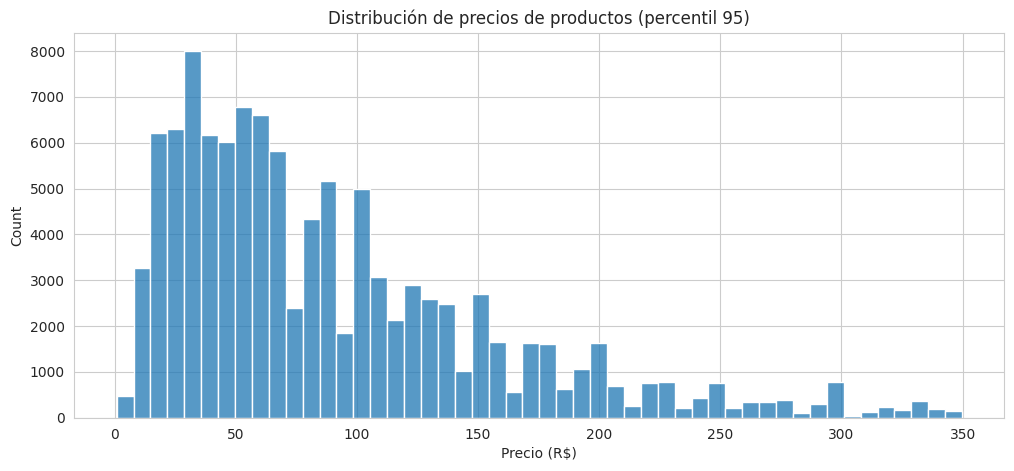

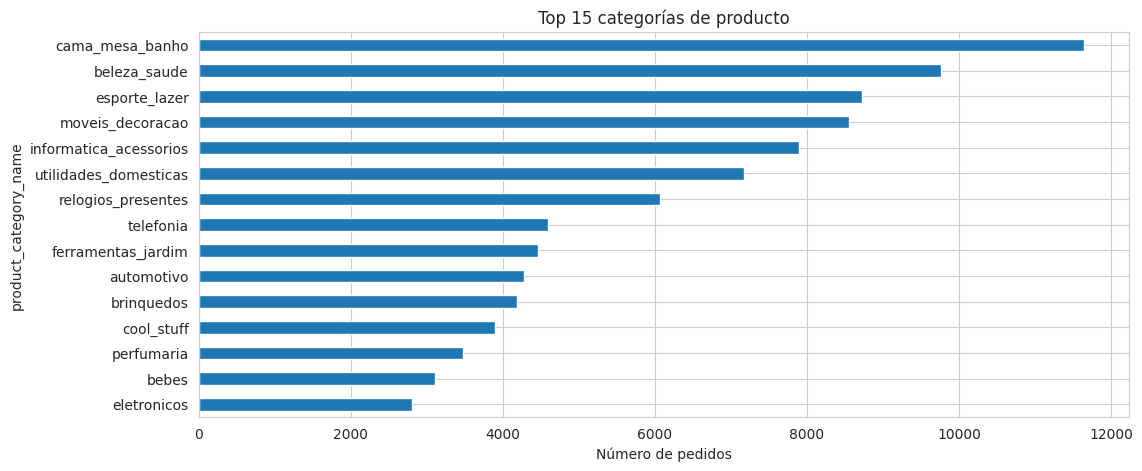

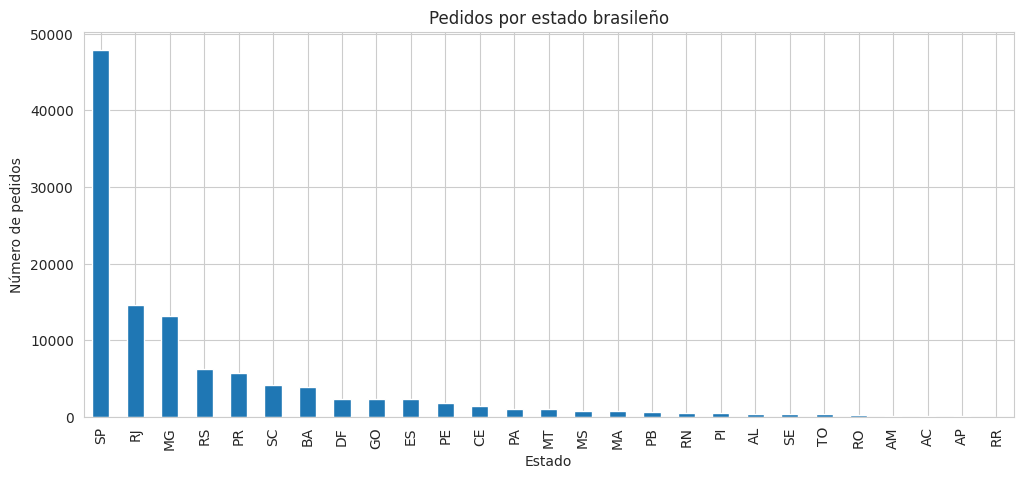

/tmp/ipykernel_773/2368428438.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('order_purchase_timestamp').resample('M').size().plot()


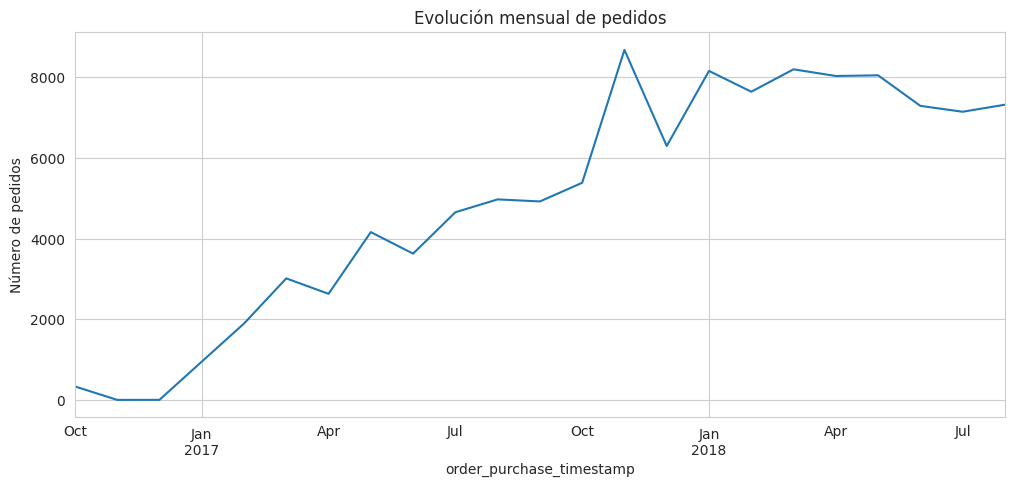

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Distribución de precio (con límite para que se vea bien)
plt.figure()
sns.histplot(df[df['price'] < df['price'].quantile(0.95)]['price'], bins=50)
plt.title('Distribución de precios de productos (percentil 95)')
plt.xlabel('Precio (R$)')
plt.show()

# 2. Top 15 categorías
plt.figure()
df['product_category_name'].value_counts().head(15).plot(kind='barh')
plt.title('Top 15 categorías de producto')
plt.xlabel('Número de pedidos')
plt.gca().invert_yaxis()
plt.show()

# 3. Pedidos por estado
plt.figure()
df['customer_state'].value_counts().plot(kind='bar')
plt.title('Pedidos por estado brasileño')
plt.xlabel('Estado')
plt.ylabel('Número de pedidos')
plt.show()

# 4. Evolución temporal (necesita convertir fecha primero)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df.set_index('order_purchase_timestamp').resample('M').size().plot()
plt.title('Evolución mensual de pedidos')
plt.ylabel('Número de pedidos')
plt.show()